# Лабораторная 1: SimpleRNN для задачи many-to-one

**Навигация:** Блок `01-RNN` · `ЛР01` · Шаг 1 курса

## Цель
Реализовать рекуррентную модель, которая по всей последовательности выдает один бинарный ответ.

Формат `many-to-one` означает: много временных шагов на входе и один итоговый выход на последовательность.


## Что нужно знать до старта

Вы сейчас здесь: `01-RNN / ЛР01` — локальная ЛР01 блока `RNN`, Шаг 1 курса.
Предыдущий шаг: общий foundations-вход и базовая sequence-подготовка.
Следующий шаг: `01-RNN / ЛР02`.

Перед началом полезно открыть:
- [Foundations entry-point](../../00-Foundations/README.md)
- [Shared-guide по формам и метрикам](../../00-Foundations/guides/01_sequence_shapes_and_metrics.md)
- [База по обозначениям и формам](guides/00_prerequisites_and_notation.md)
- [Beginner guide к этой ЛР](guides/01_simple_rnn_many_to_one_beginner.md)

Если идёте полностью без преподавателя, добавьте ещё:
- [walkthrough](guides/01_simple_rnn_walkthrough.md)
- [shared debugging playbook](../../00-Foundations/guides/04_self_study_debugging_playbook.md)

Что важно держать в голове:
- вход имеет форму `(batch, time, features)`;
- модель читает последовательность шаг за шагом и накапливает скрытое состояние `h_t`;
- здесь нужен один ответ на всю последовательность, поэтому мы смотрим на финальное состояние `h_T`;
- после `Dense(1, activation="sigmoid")` модель выдаёт вероятность класса `1`.

## Выбор runtime

Здесь вы выбираете, где и на чём запускать notebook.

Что обычно выбирать:
- `auto` — лучший вариант по умолчанию. Если TensorFlow видит GPU, будет выбран GPU. Если GPU нет, notebook спокойно останется на CPU.
- `local-cpu` — локальный запуск только на CPU, даже если видеокарта есть.
- `local-gpu` — локальный запуск с обязательным GPU. Если GPU не настроен, notebook специально остановится с понятной ошибкой.
- `colab-cpu` / `colab-gpu` — запуск в Google Colab.
- `kaggle-cpu` / `kaggle-gpu` — запуск в Kaggle Notebooks.

Что важно:
- после изменения `RUNTIME_MODE` используйте `Restart & Run All`;
- `COURSE_REPO_HTTPS_URL` нужен только для Colab/Kaggle, если репозиторий ещё не клонирован в runtime;
- пока в ячейке стоит placeholder-URL, cloud auto-bootstrap не сможет сам скачать курс;
- guide `05` отвечает на вопрос, где и как запускать notebook;
- guide `06` нужен, если вы хотите именно локальный GPU и не уверены в версиях `TensorFlow` / `CUDA`;
- локальный GPU-path курса: `Linux + NVIDIA` или `Windows -> WSL2 + Ubuntu`;
- если `local-gpu` упирается в локальные CUDA/PTX ошибки, это обычно уже проблема GPU-стека, а не notebook. В таком случае спокойно переключайтесь на `local-cpu`, `colab-gpu` или `kaggle-gpu`.

Подробные guides:
- `themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md`
- `themes/00-Foundations/guides/06_tensorflow_cuda_version_selection.md`


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "auto")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/01-RNN/lab/requirements.txt"


def _detect_notebook_platform():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


# _ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)

# from course_runtime import setup_notebook_runtime

# runtime_info = setup_notebook_runtime(
#     runtime_mode=RUNTIME_MODE,
#     course_repo_https_url=COURSE_REPO_HTTPS_URL,
#     notebook_requirements=NOTEBOOK_REQUIREMENTS,
# )
# runtime_info.as_dict()


## Интуиция задачи без формул

Представьте, что модель идёт слева направо по последовательности и держит в памяти короткое резюме всего, что уже увидела. На каждом шаге это резюме обновляется. Когда вход закончился, модель делает ровно один вывод: сумма элементов была положительной или нет.

В этой постановке нам не нужен отдельный ответ на каждом шаге. Поэтому главный объект интереса здесь не все промежуточные состояния, а последнее скрытое состояние `h_T`, в котором собрана информация о всей последовательности.


## Как проходить эту ЛР без преподавателя

Рекомендуемый self-study маршрут:
1. Прочитайте [пререквизиты](guides/00_prerequisites_and_notation.md), [beginner guide](guides/01_simple_rnn_many_to_one_beginner.md), [walkthrough](guides/01_simple_rnn_walkthrough.md) и [debugging playbook](guides/00_self_study_debugging_playbook.md).
2. Идите по notebook сверху вниз и после каждого `TODO` сразу запускайте ближайшую мини-проверку.
3. Если застряли дольше чем на 10-15 минут, открывайте walkthrough только для текущего шага.
4. [Solution notebook](solutions/01_simple_rnn_many_to_one_toy_solution.ipynb) открывайте только после собственной попытки.
5. Если состояния notebook стали подозрительными, используйте `Restart & Run All`.


## Контракт данных
Используется учебная синтетическая постановка:
- входная последовательность содержит значения `-1` и `+1`;
- целевая метка равна `1`, если сумма элементов последовательности положительна, иначе `0`.

Задача требует учета контекста по всей длине последовательности, поэтому используется рекуррентная сеть.


## Таблица форм тензоров

| Тензор | Форма | Смысл | Где используется |
|---|---|---|---|
| `X` | `(N, T, 1)` | Полный набор входных последовательностей | Генерация данных |
| `y` | `(N,)` | Бинарные целевые метки | Генерация данных |
| `X_train`, `y_train` | `(N_train, T, 1)`, `(N_train,)` | Обучающая часть | `model.fit` |
| `X_test`, `y_test` | `(N_test, T, 1)`, `(N_test,)` | Контрольная часть | `model.evaluate` |
| `probs` | `(N_test,)` | Вероятности класса `1` | `model.predict` |
| `preds` | `(N_test,)` | Бинарные предсказания после порога | Оценка качества |


## Шпаргалка по обозначениям и формам

Короткая карта обозначений:
- `N` - размер батча.
- `T` - длина последовательности.
- `F` - число признаков на шаге. В этой ЛР `F = 1`.
- `h_t` - скрытое состояние после шага `t`.
- `h_T` - финальное скрытое состояние, по которому делаем классификацию.
- `s` - сумма элементов последовательности.
- `y_hat` - предсказанная вероятность класса `1`.

Формы тензоров:
- `X_train`: `(N, T, 1)`.
- `y_train`: `(N,)`.
- выход модели: `(batch, 1)`.
- после порога `0.5` вероятность превращается в класс `0` или `1`.


## Контракт модели
- На вход `model.fit` подается `X_train` формы `(batch, time, features)` и `y_train`.
- Модель возвращает вероятность положительного класса для каждой последовательности.
- На выходе `model.predict(X_test)` получается вектор вероятностей, который преобразуется в классы порогом `0.5`.
- Функция потерь: бинарная кросс-энтропия (`binary_crossentropy`).


### Почему ответ берётся из h_T

В `many-to-one` модель должна выдать один итоговый ответ на всю последовательность. Поэтому нам не нужны все промежуточные состояния по времени. Нам нужен тот вектор памяти, который уже увидел весь вход.

Именно это и делает `h_T`: в нём собрана информация о всей последовательности от первого до последнего шага. Поэтому `Dense` получает на вход не каждый `h_t`, а только финальное состояние.


## Мини-теория
Прямой проход (forward pass) для `SimpleRNN`:

$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h), \quad
s = W_{hy}h_T + b_y, \quad
\hat{y}=\sigma(s)
$$

Итоговый логит `s` вычисляется только из последнего скрытого состояния `h_T`, что соответствует формату `many-to-one`.


## Ручной разбор одного примера

Возьмём последовательность `[-1, +1, +1, -1, +1]`.

Шаг за шагом считаем сумму:
- после первого элемента: `-1`
- после второго: `0`
- после третьего: `1`
- после четвёртого: `0`
- после пятого: `1`

Финальная сумма положительна, значит правильная метка для всей последовательности равна `1`. Это и есть смысл many-to-one: промежуточные шаги важны только как путь к одному итоговому ответу.


### Почему binary_crossentropy подходит именно здесь

В ЛР1 модель решает бинарную классификацию: на выходе есть только класс `0` или `1`. После `Dense(1, activation='sigmoid')` мы получаем одну вероятность положительного класса, а `binary_crossentropy` измеряет, насколько эта вероятность согласуется с правильной бинарной меткой.

Если модель уверенно ошибается, штраф большой. Если модель даёт осторожную вероятность, штраф мягче. Именно поэтому `binary_crossentropy` здесь информативнее, чем, например, обычная ошибка регрессии.


### Разбор одного прогноза вручную

Полезно различать три объекта:
- истинную метку `y`;
- вероятность `prob`, которую вернула модель;
- итоговый класс после порога `0.5`.

Пример:
- истинная сумма последовательности положительна, значит `y = 1`;
- модель вернула логит `1.4`, после `sigmoid` это примерно `0.80`;
- после порога `0.5` получаем предсказанный класс `1`.

Если бы вероятность была `0.49`, итоговый класс стал бы `0`, даже при очень близком числе. Именно поэтому в ЛР1 важно не путать probability и class.


In [2]:
seq = [-1, 1, 1, -1, 1]
running_sum = 0

print('sequence:', seq)
for step, value in enumerate(seq, start=1):
    running_sum += value
    print(f'step {step}: value={value:+d}, running_sum={running_sum:+d}')

label = int(running_sum > 0)
print('final label:', label)


sequence: [-1, 1, 1, -1, 1]
step 1: value=-1, running_sum=-1
step 2: value=+1, running_sum=+0
step 3: value=+1, running_sum=+1
step 4: value=-1, running_sum=+0
step 5: value=+1, running_sum=+1
final label: 1


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(42)
print('Версия TensorFlow:', tf.__version__)

Версия TensorFlow: 2.19.1


## Генерация данных
**Что сделать:** сформировать входные последовательности и бинарные метки.

**Почему:** модель должна учиться извлекать итоговый признак из всей последовательности.

**Ожидаемые формы:** `X -> (N,T,1)`, `y -> (N,)`.

**Частая ошибка:** суммирование не по временной оси или некорректная форма `y`.


### Подсказка к TODO 1-2: данные

Концептуальная подсказка:
- в ЛР1 нужен один ответ на всю последовательность, значит после агрегации должно получиться по одному числу на объект.

Implementation hint:
- сумма идёт по временной оси;
- итоговая форма `sums` должна быть `(N,)`;
- класс `1` ставится только при `sum > 0`.

Если застряли, откройте раздел про TODO 1-2 в [walkthrough](guides/01_simple_rnn_walkthrough.md).


In [4]:
def make_dataset(n_samples: int = 6000, seq_len: int = 12):
    x = np.random.choice([-1.0, 1.0], size=(n_samples, seq_len, 1)).astype(np.float32)
    # TODO 1: вычислите сумму по временной оси для каждой последовательности
    sums = x.sum(axis=1)
    # TODO 2: сформируйте бинарные метки (1 если сумма > 0, иначе 0)
    y = (sums > 0).astype(np.float32)
    y = y.reshape(-1)
    return x, y


X, y = make_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Форма X_train:', X_train.shape)
print('Форма y_train:', y_train.shape)
print('Форма X_test :', X_test.shape)
print('Форма y_test :', y_test.shape)

Форма X_train: (4800, 12, 1)
Форма y_train: (4800,)
Форма X_test : (1200, 12, 1)
Форма y_test : (1200,)


### Разбор TODO 1-2: данные

После заполнения кода проверьте себя без спойлера полного решения:
- `sums` должен давать одно число на последовательность;
- `y` должен быть бинарным вектором;
- если у вас появилась лишняя ось `(N, 1)`, это ещё не финальная форма для ЛР1.


In [5]:
# Мини-проверка данных
assert X.ndim == 3 and X.shape[-1] == 1, 'Ожидается X формы (N,T,1)'
assert y.ndim == 1, 'Ожидается y формы (N,)'
assert set(np.unique(y)).issubset({0.0, 1.0}), 'Метки должны быть бинарными'
print('Мини-проверка данных: OK')

Мини-проверка данных: OK


### Что должно получиться после шага "Данные"

Ожидаемые сигналы:
- `X` имеет форму `(N, T, 1)`;
- `y` имеет форму `(N,)`;
- мини-проверка данных проходит без ошибок;
- на 1-2 последовательностях вы можете вручную проверить сумму и метку.

Self-check checkpoint:
- выберите одну последовательность;
- сложите её элементы вручную;
- убедитесь, что итоговая метка совпадает с правилом `sum > 0`.


## Модель
**Что сделать:** собрать `Sequential`-модель через `add(...)`.

**Почему:** для `many-to-one` нужен один итоговый выход.

**Ожидаемая форма выхода:** `(batch, 1)`.

**Частая ошибка:** отсутствие компиляции модели перед обучением.


### Подсказка к TODO 3-4: модель

Концептуальная подсказка:
- в `many-to-one` нужен один итоговый выход, а не временная карта выходов.

Implementation hint:
- добавьте один `SimpleRNN` слой на 16-32 нейрона;
- завершите модель `Dense(1, activation='sigmoid')`;
- скомпилируйте её как бинарную классификацию.

Если форма выхода не сходится, откройте [walkthrough](guides/01_simple_rnn_walkthrough.md).


In [6]:
def build_model(input_shape):
    model = tf.keras.Sequential(name='simple_rnn_many_to_one')
    model.add(tf.keras.layers.Input(shape=input_shape))
    # TODO 3: добавьте слой SimpleRNN на 16-32 нейрона
    model.add(tf.keras.layers.SimpleRNN(units=16, activation='tanh'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # TODO 4: скомпилируйте модель (adam, binary_crossentropy, accuracy)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model(X_train.shape[1:])
model.summary()

Model: "simple_rnn_many_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

### Разбор TODO 3-4: модель

После заполнения блока проверьте логику, а не только синтаксис:
- есть ли один рекуррентный слой;
- заканчивается ли модель одним выходным нейроном;
- понимаете ли вы, почему `model.output_shape` должен стать `(None, 1)`.


In [7]:
# Мини-проверка модели
assert model.output_shape[-1] == 1, 'Выходной слой должен иметь 1 нейрон'
print('Мини-проверка модели: OK')

Мини-проверка модели: OK


### Что должно получиться после шага "Модель"

Ожидаемые сигналы:
- `model.summary()` показывает один рекуррентный слой и один выходной `Dense(1)`;
- мини-проверка модели проходит;
- вы можете словами объяснить, почему выход имеет форму `(batch, 1)`.

Self-check checkpoint:
- представьте один батч из 64 последовательностей;
- объясните, почему модель должна вернуть 64 вероятности, а не 64 × `T` значений.


## Трассировка одного примера через модель
Проверка показывает формы тензоров в трех точках:
1. входной пример;
2. выход рекуррентного слоя;
3. выходного слоя (вероятность класса).


In [8]:
sample_x = X_train[:1]
_ = model(sample_x)

# Выход после рекуррентного слоя
rnn_features_model = tf.keras.Model(inputs=model.inputs[0], outputs=model.layers[-2].output)
rnn_features = rnn_features_model.predict(sample_x, verbose=0)

# Выход модели
sample_prob = model.predict(sample_x, verbose=0)

print('Вход sample_x           :', sample_x.shape)
print('После рекуррентного слоя:', rnn_features.shape)
print('После выходного слоя    :', sample_prob.shape)
print('Вероятность класса 1    :', float(sample_prob[0, 0]))

Вход sample_x           : (1, 12, 1)
После рекуррентного слоя: (1, 16)
После выходного слоя    : (1, 1)
Вероятность класса 1    : 0.7254965305328369


## Как идет обучение внутри эпохи
Обучение выполняется по мини-батчам (mini-batch) и включает цикл:
1. прямой проход (`forward pass`) через все шаги времени;
2. вычисление функции потерь;
3. обратное распространение через время (`BPTT`);
4. обновление параметров оптимизатором.

Для `SimpleRNN` одна память `h_t` переносится по времени без дополнительных ворот, поэтому на длинных зависимостях возможны затухающие или взрывающиеся градиенты.


## Обучение
**Что сделать:** запустить `fit` на обучающей части с `validation_split=0.2`.

**Почему:** валидационная часть нужна для контроля обобщающей способности во время обучения, а `test` сохраняется для финальной проверки.


### Подсказка к TODO 5: обучение

Концептуальная подсказка:
- здесь не нужна новая логика модели, нужен аккуратный вызов `fit`.

Implementation hint:
- обучайте на `X_train` и `y_train`;
- используйте `validation_split=0.2`, `batch_size=64` и аргумент `epochs`;
- после обучения проверьте ключи в `history.history`.

Если история не создаётся, откройте [debugging playbook](guides/00_self_study_debugging_playbook.md).


In [9]:
def train_model(model, X_train, y_train, epochs: int = 10):
    # TODO 5: обучите модель с validation_split=0.2 и batch_size=64
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        batch_size=64,
        epochs=epochs,
        verbose=1
    )
    return history


history = train_model(model, X_train, y_train)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6055 - loss: 0.6568 - val_accuracy: 0.8677 - val_loss: 0.4520
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9177 - loss: 0.2991 - val_accuracy: 0.9448 - val_loss: 0.2048
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9445 - loss: 0.1808 - val_accuracy: 0.9583 - val_loss: 0.1503
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9643 - loss: 0.1415 - val_accuracy: 0.9812 - val_loss: 0.1219
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9799 - loss: 0.1160 - val_accuracy: 0.9927 - val_loss: 0.1020
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9875 - loss: 0.0970 - val_accuracy: 0.9969 - val_loss: 0.0865
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9922 - loss: 0.0824 - val_accuracy: 0.9990 - val_loss: 0.0732
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9940 - loss: 0.0705 - val_accuracy: 0.9990 - val_loss:

### Разбор TODO 5: обучение

После заполнения блока проверьте, что вы понимаете каждый аргумент `fit`:
- на каких данных модель учится;
- какая доля уходит на validation;
- почему `epochs` и `batch_size` влияют на кривые обучения.


In [10]:
# Мини-проверка обучения
assert 'loss' in history.history and 'val_loss' in history.history
assert 'accuracy' in history.history and 'val_accuracy' in history.history
print('Последняя val_accuracy:', float(history.history['val_accuracy'][-1]))
print('Мини-проверка обучения: OK')

Последняя val_accuracy: 1.0
Мини-проверка обучения: OK


### Что должно получиться после шага "Обучение"

Ожидаемые сигналы:
- в `history.history` есть `loss`, `val_loss`, `accuracy`, `val_accuracy`;
- `val_accuracy` уходит заметно выше случайного уровня;
- кривая `loss` имеет понятный нисходящий тренд.

Self-check checkpoint:
- можете ли вы объяснить, почему высокая train-метрика при слабой validation — это не победа, а тревожный сигнал?


## Оценка и диагностика
На этом этапе вычисляются:
- значение функции потерь на `test`;
- точность (`accuracy`) на `test`;
- ручная проверка точности после порогового преобразования вероятностей.


### Подсказка к TODO 6: метрики

Концептуальная подсказка:
- модель уже дала вероятности, но метрика в конце сравнивает классы.

Implementation hint:
- сначала получите `preds` через порог `0.5`;
- затем сравните `preds` и `y_test` поэлементно;
- усредните совпадения и сравните результат со встроенной `accuracy`.

Если застряли, откройте [walkthrough](guides/01_simple_rnn_walkthrough.md).


In [11]:
def evaluate_model(model, X_test, y_test):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    probs = model.predict(X_test, verbose=0).reshape(-1)
    # TODO 6: преобразуйте вероятности в классы порогом 0.5
    preds = (probs >= 0.5).astype(np.float32)
    acc_manual = (preds == y_test).mean()
    return {
        'loss': float(loss),
        'accuracy': float(acc),
        'accuracy_manual': float(acc_manual),
        'probs': probs,
        'preds': preds,
    }


metrics = evaluate_model(model, X_test, y_test)
print({k: v for k, v in metrics.items() if k in ('loss', 'accuracy', 'accuracy_manual')})

{'loss': 0.04836243763566017, 'accuracy': 0.996666669845581, 'accuracy_manual': 0.9966666666666667}


### Разбор TODO 6: метрики

После заполнения блока проверьте себя по смыслу:
- где именно у вас заканчиваются вероятности и начинаются классы;
- почему ручная метрика должна почти совпасть со встроенной;
- почему сравнение `probs == y_test` было бы неверным.


In [12]:
# Мини-проверка метрик
assert 0.0 <= metrics['accuracy'] <= 1.0
assert abs(metrics['accuracy'] - metrics['accuracy_manual']) < 0.02
if metrics['accuracy'] >= 0.90:
    print('Целевой порог достигнут: accuracy >= 0.90')
else:
    print('Целевой порог не достигнут: проверьте данные, модель и параметры обучения')

Целевой порог достигнут: accuracy >= 0.90


### Что должно получиться после шага "Метрики"

Ожидаемые сигналы:
- `accuracy` лежит в диапазоне `[0, 1]`;
- `accuracy_manual` почти совпадает со встроенной `accuracy`;
- при корректной реализации обычно достигается `accuracy >= 0.90`.

Self-check checkpoint:
- built-in `accuracy` и `accuracy_manual` должны различаться очень мало;
- если разница большая, почти всегда проблема в форме `preds` или в пороге `0.5`.


## Как читать графики и метрики

В этой ЛР главные сигналы такие:
- `loss` показывает, насколько далеко вероятности модели от правильных бинарных ответов;
- `accuracy` считает долю правильно классифицированных последовательностей;
- если `train_accuracy` и `val_accuracy` вместе низкие, модель недообучена или сломан pipeline;
- если `train_accuracy` высокая, а `val_accuracy` заметно хуже, это уже сигнал переобучения.

При разборе конкретного предсказания полезно отделять три сущности:
- `logit` или значение до сигмоиды;
- вероятность после `sigmoid`;
- класс после порога `0.5`.

Ошибка может появиться на любом из этих этапов: в данных, в вычислении вероятности или в неправильном превращении вероятности в класс.


## Что ожидать на практике
- В начале обучения `loss` быстро снижается, затем стабилизируется.
- Если `train_accuracy` растет, а `val_accuracy` не растет, вероятно переобучение.
- Если обе точности низкие, вероятно недообучение или ошибка в разметке/формах данных.
- Для этой постановки при корректной реализации обычно достигается `accuracy >= 0.90`.


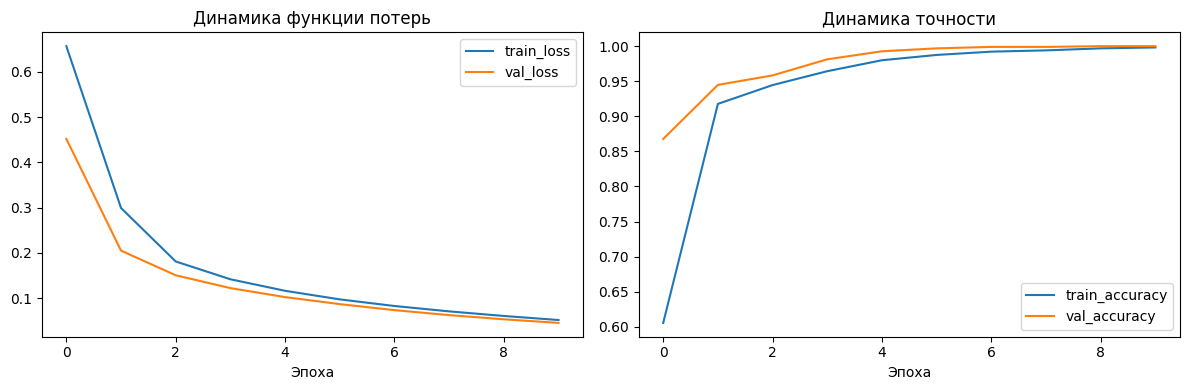

In [13]:
# Визуализация динамики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Динамика функции потерь')
plt.xlabel('Эпоха')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Динамика точности')
plt.xlabel('Эпоха')
plt.legend()

plt.tight_layout()
plt.show()

## Если не получилось с первого раза

Идите по короткому маршруту, а не переписывайте весь notebook с нуля:
1. Если не сходятся формы, вернитесь в [пререквизиты](guides/00_prerequisites_and_notation.md).
2. Если неясна логика `many-to-one`, откройте [beginner guide](guides/01_simple_rnn_many_to_one_beginner.md).
3. Если застряли на конкретном `TODO`, откройте [walkthrough](guides/01_simple_rnn_walkthrough.md).
4. Если traceback или состояние kernel уже путают, используйте [debugging playbook](guides/00_self_study_debugging_playbook.md).
5. Только потом сравнивайте свою попытку с solution notebook.


## Если застряли: порядок диагностики

Порядок проверки лучше держать простым: сначала данные, потом формы тензоров, потом модель, и только после этого метрики и визуализации.

1. Проверьте правило разметки: метка должна зависеть от знака финальной суммы.
2. Проверьте форму входа: `X` должен иметь вид `(N, T, 1)`, а не `(N, T)`.
3. Проверьте форму выхода модели: ожидается `(batch, 1)`.
4. Проверьте интерпретацию предсказания: `sigmoid` даёт вероятность, а класс получается только после порога `0.5`.
5. Если качество странное, вручную прогоните один маленький пример и сравните сумму, метку и прогноз.


## Чек-лист перед сдачей

- Понимаю, почему задача относится к many-to-one.
- Могу объяснить роль `h_T` и почему ответ берётся в конце.
- Проверил форму данных `(N, T, 1)` и форму выхода `(batch, 1)`.
- Понимаю связь `sigmoid -> probability -> class`.
- Могу вручную разобрать один пример и предсказать правильную метку без запуска модели.


## Как использовать решение без самообмана

Когда дойдёте до [solution notebook](solutions/01_simple_rnn_many_to_one_toy_solution.ipynb), используйте его так:
1. Не открывайте всё решение заранее.
2. Найдите конкретный шаг, где вы застряли.
3. Сравните только этот блок, а потом закройте решение и допишите свой notebook сами.
4. После исправления снова прогоните мини-проверки и убедитесь, что понимаете, почему они стали зелёными.

Цель решения — не заменить вашу попытку, а помочь восстановить её осмысленно.


## Мини-экзамен

1. Почему в `many-to-one` ответ берётся из `h_T`, а не из каждого `h_t`?
2. По какой оси в ЛР1 считается сумма и почему?
3. Что означает форма `model.output_shape == (None, 1)`?
4. Почему здесь подходит `binary_crossentropy`?
5. Как из вероятности получить класс?
6. Почему `accuracy_manual` должна почти совпасть со встроенной `accuracy`?


## Что дальше

Следующий шаг курса: Шаг 2 = `01-RNN / ЛР02`.

На следующей лабораторной изменятся сразу три вещи:
- ответ понадобится на каждом шаге времени, а не один раз в конце;
- модель должна будет вернуть всю последовательность скрытых состояний;
- появится пара метрик `token_accuracy` и `sequence_accuracy`.


## Вопросы для самопроверки
1. Почему для `many-to-one` используется только финальное состояние `h_T`?
2. Что означает форма входа `(batch, time, features)` в терминах задачи?
3. Как интерпретировать разрыв между `train_accuracy` и `val_accuracy`?
4. Зачем нужна отдельная контрольная выборка `test`?


## Типичные ошибки (симптом -> причина -> исправление)
- `accuracy` около `0.5` -> неверная разметка классов -> проверить правило `sum > 0`.
- Ошибка формы тензоров -> перепутан порядок осей -> привести вход к `(N,T,1)`.
- Обучение нестабильно -> слишком большой шаг обучения (`learning rate`) -> уменьшить шаг или проверить оптимизатор.
- Слабая валидация при высоком train -> переобучение -> уменьшить модель или число эпох.
